In [25]:
library(tidyverse)  
library(dplyr) 
library(ggplot2) 
library(gridExtra)
library(reshape2)

## Question 4

In [26]:
# Load data
tic_data <- read_csv("input/ticker_data.csv", show_col_types = FALSE) 
appl_ret <- tic_data[tic_data$TICKER=="AAPL", ][1:2500, "RET"] * 100
pfe_ret  <- tic_data[tic_data$TICKER=="PFE", ][1:2500, "RET"] * 100
jnj_ret  <- tic_data[tic_data$TICKER=="JNJ", ][1:2500, "RET"] * 100
mrk_ret  <- tic_data[tic_data$TICKER=="MRK", ][1:2500, "RET"] * 100

pfe_full  <- tic_data[tic_data$TICKER=="PFE", ]["RET"] * 100
jnj_full  <- tic_data[tic_data$TICKER=="JNJ", ]["RET"] * 100
mrk_full  <- tic_data[tic_data$TICKER=="MRK", ]["RET"] * 100

asset_rets <- list(PFE = pfe_ret, JNJ = jnj_ret, MRK = mrk_ret)
asset_full <- list(PFE = pfe_full, JNJ = jnj_full, MRK = mrk_full)

### GARCH Model

In [27]:
# Function for computing the volatilities for given GARCH model
vol_garch <- function(par, data){
    # Define parameters
    mu <- par[1]
    omega <- par[2]
    alpha <- par[3]
    beta <- par[4]

    # Implementing statistical model
    data <- data[["RET"]]
    n <- length(data)
    sig2 <- rep(0,n)
    x_sub <- data[1:50]
    xbar <- mean(x_sub)
    sig2[1] <- mean((x_sub - xbar)^2)

    # Recursive variance loop
    for (t in 2:n){
        sig2[t] <- omega + alpha * ((data[t-1] - mu) / sqrt(sig2[t-1]))^2 + beta * sig2[t-1]
    }
    
    return(sqrt(sig2))
}

In [28]:
# Function for computing the loglikelihood for given GARCH model
ll_garch <- function(par, data){
    # Define parameters
    mu <- par[1]
    omega <- par[2]
    alpha <- par[3]
    beta <- par[4]
    v <- par[5]

    # Check constraints
    if (v <= 2) {
        return(1e10)
    }

    # Implementing statistical model
    data <- data[["RET"]]
    n <- length(data)
    sig2 <- rep(0,n)
    x_sub <- data[1:50]
    xbar <- mean(x_sub)
    sig2[1] <- mean((x_sub - xbar)^2)

    # Recursive variance loop
    for (t in 2:n){
        sig2[t] <- omega + alpha * ((data[t-1] - mu) / sqrt(sig2[t-1]))^2 + beta * sig2[t-1]
    }
    if (any(!is.finite(sig2)) || any(sig2 <= 0)) return(1e10)

    # Compute loglikelihood
    ll <- n * (lgamma((v + 1) / 2) - lgamma(v / 2) - 0.5 * log(v * pi)) - 0.5 * sum(log(sig2)) - ((v + 1) / 2) * sum(log(1 + (data - mu)^2 / (v * sig2)))

    return(-ll)
}

### GARCH-M Model

In [29]:
# Function for computing the volatilities for given GARCH-M model
vol_garch_m <- function(par, data){
    # Define parameters
    mu <- par[1]
    lambda <- par[2]
    omega <- par[3]
    alpha <- par[4]
    beta <- par[5]

    # Implementing statistical model
    data <- data[["RET"]]
    n <- length(data)
    sig2 <- rep(0,n)
    x_sub <- data[1:50]
    xbar <- mean(x_sub)
    sig2[1] <- mean((x_sub - xbar)^2)

    # Recursive variance loop
    for (t in 2:n){
        sig2[t] <- omega + alpha * ((data[t-1] - mu - lambda * sig2[t-1]) / sqrt(sig2[t-1]))^2 + beta * sig2[t-1]
    }

    return(sqrt(sig2))
}

In [30]:
# Function for computing the loglikelihood for given GARCH-M model
ll_garch_m <- function(par, data){
    # Define parameters
    mu <- par[1]
    lambda <- par[2]
    omega <- par[3]
    alpha <- par[4]
    beta <- par[5]
    v <- par[6]

    # Check constraints
    if (v <= 2) {
        return(1e10)
    }

    # Implementing statistical model
    data <- data[["RET"]]
    n <- length(data)
    sig2 <- rep(0,n)
    x_sub <- data[1:50]
    xbar <- mean(x_sub)
    sig2[1] <- mean((x_sub - xbar)^2)

    # Recursive variance loop
    for (t in 2:n){
        sig2[t] <- omega + alpha * ((data[t-1] - mu - lambda * sig2[t-1]) / sqrt(sig2[t-1]))^2 + beta * sig2[t-1]
    }
    if (any(!is.finite(sig2)) || any(sig2 <= 0)) return(1e10)

    # Compute loglikelihood
    ll <- n * (lgamma((v + 1) / 2) - lgamma(v / 2) - 0.5 * log(v * pi)) - 0.5 * sum(log(sig2)) - ((v + 1) / 2) * sum(log(1 + (data - mu - lambda * sig2)^2 / (v * sig2)))
    return(-ll)
}

### GARCH-M-L Model

In [31]:
# Function for computing the loglikelihood for given GARCH-M-L model
vol_garch_ml <- function(par, data){
    # Define parameters
    mu <- par[1]
    lambda <- par[2]
    omega <- par[3]
    alpha <- par[4]
    beta <- par[5]
    delta <- par[6]
    gamma <- par[7]

    # Implementing statistical model
    data <- data[["RET"]]
    n <- length(data)
    sig2 <- rep(0,n)
    x_sub <- data[1:50]
    xbar <- mean(x_sub)
    sig2[1] <- mean((x_sub - xbar)^2)

    # Recursive variance loop
    for (t in 2:n){
        sig2[t] <- omega + (alpha + delta * tanh(-gamma * data[t-1])) * ((data[t-1] - mu - lambda * sig2[t-1]) / sqrt(sig2[t-1]))^2 + beta * sig2[t-1]
    }

    return(sqrt(sig2))
}

In [32]:
# Function for computing the loglikelihood for given GARCH-M-L model
ll_garch_ml <- function(par, data){
    # Define parameters
    mu <- par[1]
    lambda <- par[2]
    omega <- par[3]
    alpha <- par[4]
    beta <- par[5]
    delta <- par[6]
    gamma <- par[7]
    v <- par[8]

    # Check constraints
    if (v <= 2) {
        return(1e10)
    }

    # Implementing statistical model
    data <- data[["RET"]]
    n <- length(data)
    sig2 <- rep(0,n)
    x_sub <- data[1:50]
    xbar <- mean(x_sub)
    sig2[1] <- mean((x_sub - xbar)^2)

    # Recursive variance loop
    for (t in 2:n){
        sig2[t] <- omega + (alpha + delta * tanh(-gamma * data[t-1])) * ((data[t-1] - mu - lambda * sig2[t-1]) / sqrt(sig2[t-1]))^2 + beta * sig2[t-1]
    }
    if (any(!is.finite(sig2)) || any(sig2 <= 0)) return(1e10)

    # Compute penalized loglikelihood
    ll <- n * (lgamma((v + 1) / 2) - lgamma(v / 2) - 0.5 * log(v * pi)) - 0.5 * sum(log(sig2)) - ((v + 1) / 2) * sum(log(1 + (data - mu - lambda * sig2)^2 / (v * sig2)))
    ll_pen <- ll - 0.001 * gamma^2

    return(-ll_pen)
}

# Function for computing AIC and BIC
compute_AIC_BIC <- function(logL, n, k){
    aic = 2 * k - 2 * logL 
    bic =  k * log(n) - 2 * logL
    return(c(aic, bic))
}

### AIC, BIC

In [33]:
# Function for computing AIC and BIC
compute_AIC_BIC <- function(logL, n, k){
    aic = 2 * k - 2 * logL 
    bic =  k * log(n) - 2 * logL
    return(c(aic, bic))
}

### NIC

In [34]:
# Set up shock grid
x <- seq(-3, 3, length.out = 500)

# Function for computing NIC for GARCH
nic_garch <- function(est_par, data, x) {
  est_omega <- est_par[[2]]
  est_alpha <- est_par[[3]]
  est_beta <- est_par[[4]]
  sig2_bar <- var(data[["RET"]])
  
  nic <- est_omega + est_alpha * (x^2) + est_beta * sig2_bar
  return(nic)
}

# Function for computing NIC for GARCH-M
nic_garch_m <- function(est_par, data, x) {
  est_omega <- est_par[[3]]
  est_alpha <- est_par[[4]]
  est_beta <- est_par[[5]]
  sig2_bar <- var(data[["RET"]])
  
  nic <- est_omega + est_alpha * (x^2) + est_beta * sig2_bar
  return(nic)
}

# Function for computing NIC for GARCH-M-L
nic_garch_ml <- function(est_par, data, x) {
  est_mu <- est_par[[1]]
  est_lambda <- est_par[[2]]
  est_omega <- est_par[[3]]
  est_alpha <- est_par[[4]]
  est_beta <- est_par[[5]]
  est_delta <- est_par[[6]]
  est_gamma <- est_par[[7]]
  sig2_bar <- var(data[["RET"]])
  
  x_lag <- est_mu + est_lambda * sig2_bar + sqrt(sig2_bar) * x
  
  nic <- est_omega + (est_alpha + est_delta * tanh(-est_gamma * x_lag)) * (x^2) + est_beta * sig2_bar
  return(nic)
}

### Results

In [35]:
# Estimate parameters, AIC and BIC for each ticker using initial parameters
ticker_vols <- c()
ticker_nics <- c()
for(ticker in names(asset_rets)){
    ini_s2 <- var(asset_rets[[ticker]][["RET"]])
    
    # GARCH model
    print("GARCH | Ticker, Estimated Parameters: mu, omega, alpha, beta, v, LogL, convergence, AIC, BIC")
    garch_par <- c(mu = 0, omega = ini_s2/50, alpha = 0.05, beta = 0.9, v = 10) # Define initial parameters
    est_garch <- optim(par = garch_par, fn = function(p) ll_garch(p, asset_rets[[ticker]]), method = "BFGS") # Estimate model 
    aic_bic_garch <- compute_AIC_BIC(-est_garch$value, nrow(asset_rets[[ticker]]), length(garch_par)) # Compute AIC and BIC
    cat(ticker, round(est_garch$par, 3), round(-est_garch$value, 0), est_garch$convergence, round(aic_bic_garch[1], 0), round(aic_bic_garch[2], 0), "\n")
    ticker_nics[[ticker]][["GARCH"]] <- nic_garch(est_garch$par, asset_full[[ticker]], x) # Compute NIC

    # GARCH-M model
    print("GARCH-M | Ticker, Estimated Parameters: mu, lambda, omega, alpha, beta, v, LogL, convergence, AIC, BIC")
    garch_m_par <- c(mu = 0, lambda = 0, omega = ini_s2/50, alpha = 0.05, beta = 0.9, v = 10)
    est_garch_m <- optim(par = garch_m_par, fn = function(p) ll_garch_m(p, asset_rets[[ticker]]), method = "BFGS")
    aic_bic_garch_m <- compute_AIC_BIC(-est_garch_m$value, nrow(asset_rets[[ticker]]), length(garch_m_par))
    cat(ticker, round(est_garch_m$par, 3), round(-est_garch_m$value, 0), est_garch_m$convergence, round(aic_bic_garch_m[1], 0), round(aic_bic_garch_m[2], 0), "\n") 
    ticker_nics[[ticker]][["GARCH-M"]] <- nic_garch_m(est_garch_m$par, asset_full[[ticker]], x)

    # GARCH-M-L model
    print("GARCH-M-L | Ticker, Estimated Parameters: mu, lambda, omega, alpha, beta, delta, gamma, v, LogL, convergence, AIC, BIC")
    garch_ml_par <- c(mu = 0, lambda = 0, omega = ini_s2/50, alpha = 0.05, beta = 0.9, delta = 0.01, gamma = 0.01, v = 10)
    sig_garch_ml <- vol_garch_ml(garch_ml_par, asset_full[[ticker]])
    ticker_vols[[ticker]] <- sig_garch_ml
    est_garch_ml <- optim(par = garch_ml_par, fn = function(p) ll_garch_ml(p, asset_rets[[ticker]]), method = "BFGS")
    aic_bic_garch_ml <- compute_AIC_BIC(-est_garch_ml$value, nrow(asset_rets[[ticker]]), length(garch_ml_par))
    cat(ticker, round(est_garch_ml$par, 3), round(-est_garch_ml$value, 0), est_garch_ml$convergence, round(aic_bic_garch_ml[1], 0), round(aic_bic_garch_ml[2], 0), "\n")
    ticker_nics[[ticker]][["GARCH-M-L"]] <- nic_garch_ml(est_garch_ml$par, asset_full[[ticker]], x)

}


[1] "GARCH | Ticker, Estimated Parameters: mu, omega, alpha, beta, v, LogL, convergence, AIC, BIC"


Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2

PFE 0.037 -0.027 0.037 0.961 4.654 -3769 0 7549 7578 
[1] "GARCH-M | Ticker, Estimated Parameters: mu, lambda, omega, alpha, beta, v, LogL, convergence, AIC, BIC"


Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2

PFE -0.006 0.087 -0.025 0.036 0.959 4.682 -3767 0 7546 7581 
[1] "GARCH-M-L | Ticker, Estimated Parameters: mu, lambda, omega, alpha, beta, delta, gamma, v, LogL, convergence, AIC, BIC"


...

MRK 0.066 0.014 0.039 0.906 4.499 -3893 0 7796 7825 
[1] "GARCH-M | Ticker, Estimated Parameters: mu, lambda, omega, alpha, beta, v, LogL, convergence, AIC, BIC"


Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2

MRK 0.078 -0.015 0.015 0.04 0.904 4.503 -3893 0 7798 7833 
[1] "GARCH-M-L | Ticker, Estimated Parameters: mu, lambda, omega, alpha, beta, delta, gamma, v, LogL, convergence, AIC, BIC"


Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2[t - 1]):
"NaNs produced"
Warning message in sqrt(sig2

MRK -0.045 0.116 0.02 0.041 0.905 0.039 2.465 4.723 -3868 0 7753 7799 


## Question 5

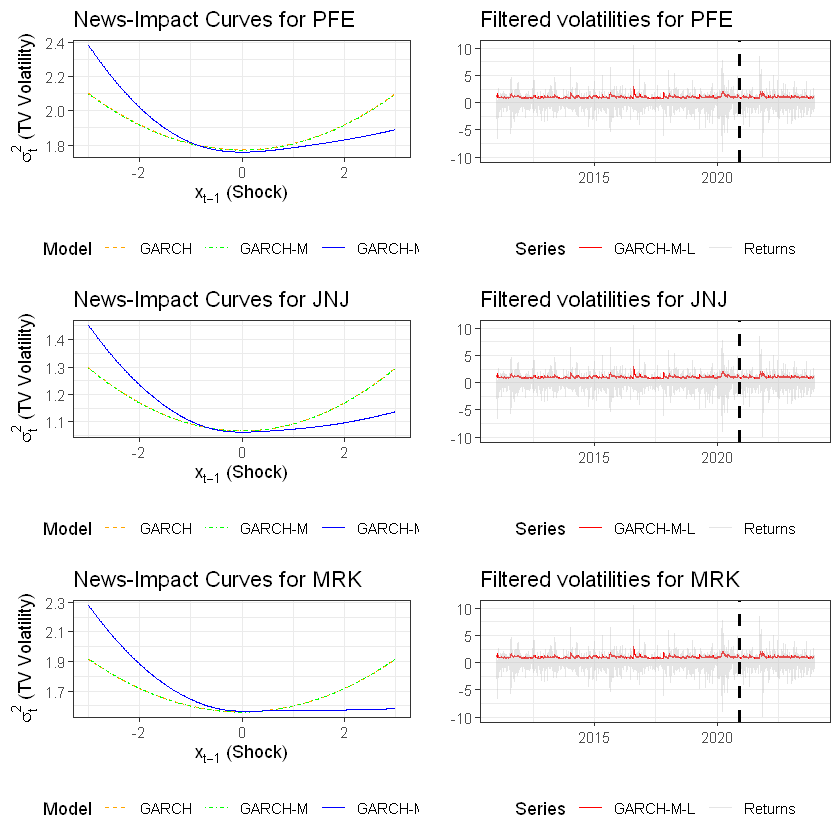

In [36]:
plot_dates <- tic_data[tic_data$TICKER=="AAPL", ][["date"]]
oos_line <- tic_data[tic_data$TICKER=="AAPL", ][[2500, "date"]]

combined_plots <- list()
for(ticker in names(ticker_vols)){
    # Plot the NIC for each ticker, for each model
    df_nic <- data.frame(
        x = x,
        GARCH = ticker_nics[[ticker]][["GARCH"]],
        GARCH_M = ticker_nics[[ticker]][["GARCH-M"]],
        GARCH_ML = ticker_nics[[ticker]][["GARCH-M-L"]]
    )

    plot_nic <- ggplot(df_nic, aes(x = x)) +
        geom_line(aes(y = GARCH, color = "GARCH"), linetype = "dashed") +
        geom_line(aes(y = GARCH_M, color = "GARCH-M"), linetype = "dotdash") +
        geom_line(aes(y = GARCH_ML, color = "GARCH-M-L"), linetype = "solid") +
        scale_color_manual(values = c("GARCH" = "orange", "GARCH-M" = "green", "GARCH-M-L" = "blue")) +
        labs(title = paste("News-Impact Curves for", ticker), x = expression(x[t-1] ~ "(Shock)"), y = expression(sigma[t]^2 ~ "(TV Volatility)"), color = "Model") +
        theme_bw() +
        theme(legend.position = "bottom")

    # Plot the volatility for each ticker for the GARCH-M-L model
    plot_vol <- ggplot() +
        geom_line(aes(x = plot_dates, y = ticker_vols[[ticker]], color = "GARCH-M-L")) +
        geom_line(aes(x = plot_dates, y = asset_full[[ticker]][["RET"]], color = "Returns"), alpha = 0.4) +
        geom_vline(xintercept = oos_line, linetype = "dashed", color = "black", linewidth = 1) +
        scale_color_manual(values = c("Returns" = "gray", "GARCH-M-L" = "red")) +
        labs(title = paste("Filtered volatilities for", ticker), x = "", y = "", color = "Series") +
        theme_bw() +
        theme(legend.position = "bottom")
        
# Store both plots in the list sequentially
  combined_plots[[paste0(ticker, "_vol")]] <- plot_nic
  combined_plots[[paste0(ticker, "_nic")]] <- plot_vol
}

grid <- grid.arrange(grobs = combined_plots, ncol = 2, nrow = 3)
ggsave("output/q5.png", grid, width = 10, height = 8, dpi =300)
